In [6]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

with open("../data/processed/churn_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train_resampled = data['X_train_resampled']
y_train_resampled = data['y_train_resampled']
X_test_prep = data['X_test_prep']
y_test = data['y_test']
y_train = data['y_train']
feature_names = data['feature_names']

ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost_tuned": XGBClassifier(random_state=42, 
                                   use_label_encoder=False, 
                                   eval_metric='logloss',
                                   scale_pos_weight=ratio)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_prep)
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Report for {name}")
    print(f"ROC-AUC score: {roc_auc:.4f}")

    report = classification_report(y_test, y_pred, output_dict=True)
    class_1 = report["1"]
    print(f"Precision (class 1): {class_1['precision']:.2f}")
    print(f"Recall (Class 1):    {class_1['recall']:.2f}")
    print(f"F1-Score (Class 1):  {class_1['f1-score']:.2f}")
    print("-" * 30)

Training Logistic Regression...
Report for Logistic Regression
ROC-AUC score: 0.7926
Precision (class 1): 0.25
Recall (Class 1):    0.72
F1-Score (Class 1):  0.37
------------------------------
Training Random Forest...
Report for Random Forest
ROC-AUC score: 0.7733
Precision (class 1): 0.32
Recall (Class 1):    0.08
F1-Score (Class 1):  0.13
------------------------------
Training XGBoost_tuned...


c:\Users\ThePC\Desktop\ML\bank-customer-churn\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:51:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Report for XGBoost_tuned
ROC-AUC score: 0.7706
Precision (class 1): 0.23
Recall (Class 1):    0.75
F1-Score (Class 1):  0.35
------------------------------


                 Feature  Importance
7          numcomplaints    0.180262
6          numofproducts    0.152494
3           credit_score    0.119077
0   number_of_dependents    0.060208
9      products_per_year    0.057428
2        customer_tenure    0.050032
1                 income    0.049824
5      outstanding_loans    0.049288
4  credit_history_length    0.049018
8          tenure_to_age    0.047621


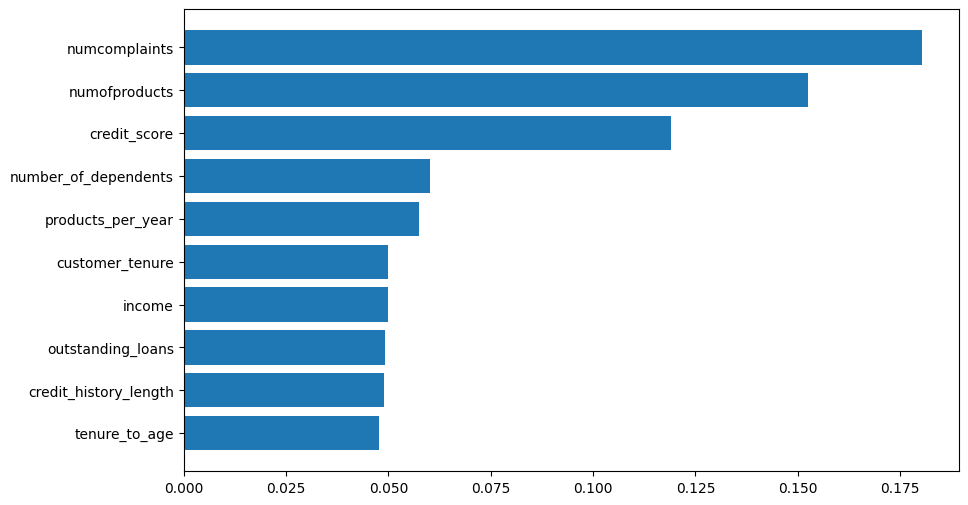

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

rf_model = models['Random Forest']
importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'].head(10), feature_imp_df['Importance'].head(10))
plt.gca().invert_yaxis()
plt.show()

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 1, 2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss',
    scale_pos_weight=ratio
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_resampled, y_train_resampled)
print(f"Best params: {random_search.best_params_}")
best_xgb_model = random_search.best_estimator_


y_pred_tuned = best_xgb_model.predict(X_test_prep)
y_pred_proba = best_xgb_model.predict_proba(X_test_prep)[:, 1]
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba)

print(f"--- Report for TUNED XGBoost ---")
print(f"ROC-AUC Score: {roc_auc_tuned:.4f}")

report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)
class_1_tuned = report_tuned['1']

print(f"Precision (Class 1): {class_1_tuned['precision']:.2f}")
print(f"Recall (Class 1):    {class_1_tuned['recall']:.2f}")
print(f"F1-Score (Class 1):  {class_1_tuned['f1-score']:.2f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\ThePC\Desktop\ML\bank-customer-churn\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:52:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 1, 'colsample_bytree': 1.0}
--- Report for TUNED XGBoost ---
ROC-AUC Score: 0.7277
Precision (Class 1): 0.24
Recall (Class 1):    0.39
F1-Score (Class 1):  0.30


In [9]:
from sklearn.ensemble import VotingClassifier

log_reg = LogisticRegression(random_state=42, max_iter=1000)
xgb_model = models["XGBoost_tuned"]

# Creating ansemble
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg), 
        ('xgb', xgb_model)
    ],
    voting='soft',
    weights=[1, 1]
)

print("Training Ensemble Model (Voting)...")
voting_clf.fit(X_train_resampled, y_train_resampled)

# Checking
y_pred_ensemble = voting_clf.predict(X_test_prep)
y_prob_ensemble = voting_clf.predict_proba(X_test_prep)[:, 1]

roc_auc_ensemble = roc_auc_score(y_test, y_prob_ensemble)

print(f"\n--- Report for ENSEMBLE ---")
print(f"ROC-AUC Score: {roc_auc_ensemble:.4f}")

report_ens = classification_report(y_test, y_pred_ensemble, output_dict=True)
class_1_ens = report_ens['1']

print(f"Precision (Class 1): {class_1_ens['precision']:.2f}")
print(f"Recall (Class 1):    {class_1_ens['recall']:.2f}")
print(f"F1-Score (Class 1):  {class_1_ens['f1-score']:.2f}")

Training Ensemble Model (Voting)...


c:\Users\ThePC\Desktop\ML\bank-customer-churn\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:52:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Report for ENSEMBLE ---
ROC-AUC Score: 0.7870
Precision (Class 1): 0.24
Recall (Class 1):    0.75
F1-Score (Class 1):  0.36


In [10]:
import pickle

with open('../data/processed/ansemble.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)